Instalation list:

In [1]:
!pip install ultralytics
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.7 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


Import list

In [2]:
from ultralytics import YOLO
from roboflow import Roboflow 
import os
import matplotlib.pyplot as plt
import cv2 

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Download the dataset

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="swSctkAMwBlBTcEtiyzl")
project = rf.workspace("mike-cox-szip2").project("brain-tumor-omjcy")
version = project.version(3)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Brain-Tumor-3 in yolov8:: 100%|██████████| 8834/8834 [00:01<00:00, 7490.66it/s]


### Check and visulaize the data

/content/Brain-Tumor-3
Dataset path: /content/Brain-Tumor-3

Main folder content:
['train', 'valid', 'README.roboflow.txt', 'test', 'data.yaml', 'README.dataset.txt']

Train images:
['Tr-me_0719_jpg.rf.ec47f8ec097c280fc30aa27d91118776.jpg', 'Tr-no_0813_jpg.rf.6fd0fd421df4cd781f0d97e55be281c0.jpg', 'Tr-me_1257_jpg.rf.e41c53021e83fa19044ef07dfed67adb.jpg', 'Tr-no_0818_jpg.rf.c4b9188fa57be95b11e9950569ebd67a.jpg', 'Tr-pi_0350_jpg.rf.293b0b1d72e0b63d1c0b89d2dcaabf65.jpg']

Train labels:
['Tr-pi_1075_jpg.rf.aff94209cabba118ada3cfcbae7cad54.txt', 'Te-pi_0069_jpg.rf.3666ed201b37500c95e95a8e69a7bc69.txt', 'Tr-pi_1448_jpg.rf.921a526b145f0c2531a1c08cc4763dd7.txt', 'Tr-pi_0279_jpg.rf.8bf5c3e1d8fd6cd503eaef0e5a0a3c25.txt', 'Tr-no_0411_jpg.rf.e1e925b44c8657b14d0803988a7e82eb.txt']


()

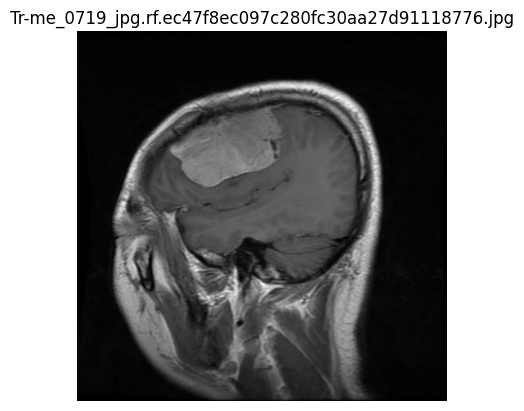

In [4]:
dataset = project.version(3).download("yolov11")
print(dataset.location)

dataset_path = dataset.location

print("Dataset path:", dataset_path)
print("\nMain folder content:")
print(os.listdir(dataset_path))

print("\nTrain images:")
print(os.listdir(os.path.join(dataset_path, "train", "images"))[:5])

print("\nTrain labels:")
print(os.listdir(os.path.join(dataset_path, "train", "labels"))[:5])



# pick one image
img_name = os.listdir(os.path.join(dataset_path, "train", "images"))[0]

img_path = os.path.join(dataset_path, "train", "images", img_name)

# read image
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(img_name)
plt.axis("off")
plt.show
() 

### Check the data.yaml

In [5]:
with open(os.path.join(dataset_path, "data.yaml"), "r") as f:
    print(
f.read
()) 

names:
- Brain-With-Meningioma-Tumour
- Brain-With-Pituitary-Tumour
- Brain-With-Tumour
- Healthy Brain
- Tumor
nc: 5
roboflow:
  license: CC BY 4.0
  project: brain-tumor-omjcy
  url: https://universe.roboflow.com/mike-cox-szip2/brain-tumor-omjcy/dataset/3
  version: 3
  workspace: mike-cox-szip2
test: ../test/images
train: ../train/images
val: ../valid/images



### Training

In [6]:
# Load segmentation model
model = YOLO("yolo11n-seg.pt")  # nano segmentation version

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    augment=True
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Brain-Tumor-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b9bb63b8b30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0

🔹 1️⃣ Model Summary

YOLO11n-seg summary:

204 layers

2,843,583 parameters

9.7 GFLOPs


This means:

Nano segmentation model

~2.8 million parameters

Lightweight model

Good for fast training

Overriding model.yaml nc=80 with nc=5

This means:

Pretrained model was trained on COCO (80 classes)

Your dataset has 5 classes

Model automatically adjusted output layer

Explain the output:

Box(P) = 0.854

Box(R) = 0.612

Box mAP50 = 0.863

Box mAP50-95 = 0.726

Mask(P) = 0.857

Mask(R) = 0.610

Mask mAP50 = 0.863

Mask mAP50-95 = 0.779

Let me explain each:

📌 Precision (P)

High precision = few false positives.

0.85 → Very good.

📌 Recall (R)

Recall = how many real tumors detected.

0.61 → Moderate.

Model misses some tumors.

📌 mAP50

Mean Average Precision at IoU=0.5.

0.863 → Very strong performance for epoch 1.

📌 mAP50-95

Stricter metric (harder).

0.726 → Good for early training.

### Loss Terms Explained

During training:

box_loss   → bounding box accuracy

seg_loss   → mask accuracy

cls_loss   → classification accuracy

dfl_loss   → box refinement quality

You want all of them to go down over epochs.

They are decreasing → good sign.

## Downlaoding the model

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [19]:
!cp /content/runs/segment/train/weights/best.pt /content/drive/MyDrive/

## Local testing

In [ ]:
from ultralytics import YOLO

# Load model
model = YOLO("C:/Projects/SAIR/Part 2/Lab submissions/SAIR_Courses/4_PyTorch/lab_assignments/Eithar_Ismail/Lab_5/best.pt")

# Predict
results = model.predict(
    source="images/thumb_testing_image.jpg",
    imgsz=640,
    conf=0.2,
    save=True
)

print("Prediction done!")

In [24]:
import os
print(os.getcwd())

/content
